In [1]:
%pip install seaborn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import RandomOverSampler


Note: you may need to restart the kernel to use updated packages.


In [2]:
# Load the dataset
df = pd.read_csv("synthetic_diabetes_data.csv")
df.head()


,Glucose,Insulin,BloodPressure,Sweating,Nausea,Confusion,Thirst,MealStatus,Outcome
0,308,12,138,1,1,1,1,post,DKA
1,198,18,145,1,1,1,0,pre,Hyperglycemia
2,259,18,149,1,1,0,1,post,DKA
3,289,18,118,1,0,0,0,pre,DKA
4,166,11,140,0,0,0,1,post,Normal


In [3]:
# Check for missing values
df.isnull().sum()


Glucose          0
Insulin          0
BloodPressure    0
Sweating         0
Nausea           0
Confusion        0
Thirst           0
MealStatus       0
Outcome          0
dtype: int64

In [4]:
# Get a statistical summary of the dataset
df.describe()


,Glucose,Insulin,BloodPressure,Sweating,Nausea,Confusion,Thirst
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,188.262000,9.784000,125.272000,0.596000,0.588000,0.596000,0.580000
std,89.398196,6.015123,19.832516,0.491189,0.492688,0.491189,0.494053
min,40.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000
25%,109.000000,4.000000,108.000000,0.000000,0.000000,0.000000,0.000000
50%,188.500000,10.000000,125.000000,1.000000,1.000000,1.000000,1.000000
75%,266.250000,15.000000,143.000000,1.000000,1.000000,1.000000,1.000000
max,349.000000,19.000000,159.000000,1.000000,1.000000,1.000000,1.000000


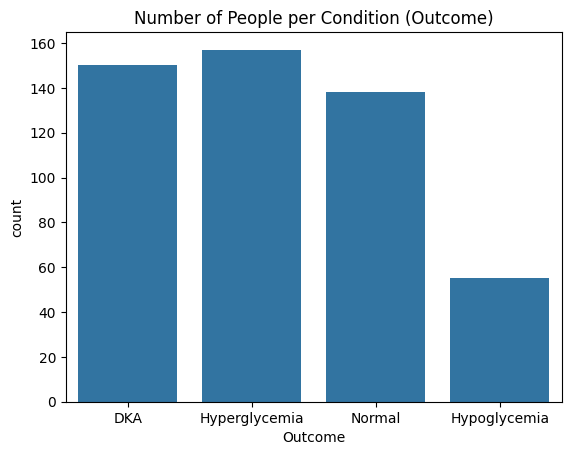

In [5]:
# Count how many of each outcome
sns.countplot(x="Outcome", data=df)
plt.title("Number of People per Condition (Outcome)")
plt.show()


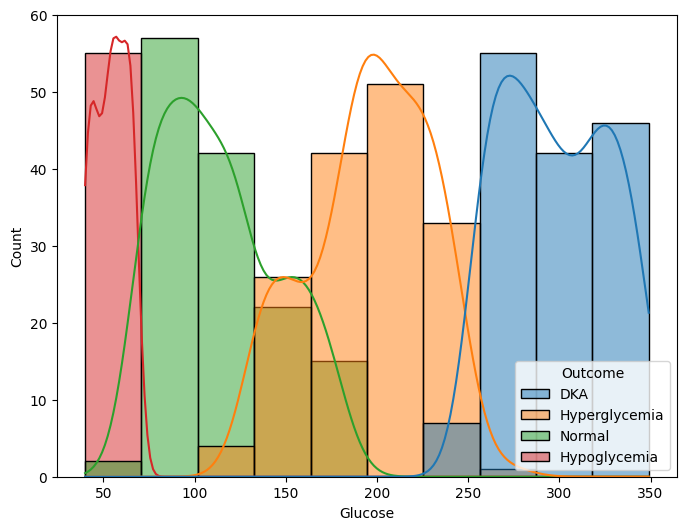

In [6]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x="Glucose", hue="Outcome", kde=True)
plt.show()

In [7]:


# Features and labels

X = df[["Glucose", "Insulin", "BloodPressure", "Sweating", "Nausea", "Confusion", "Thirst"]]
y = df["Outcome"]

# Oversample minority classes (like DKA) so all classes are balanced
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
# check new class distribution
print(y_res.value_counts())

Outcome
DKA              157
Hyperglycemia    157
Normal           157
Hypoglycemia     157
Name: count, dtype: int64


In [8]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
from sklearn.metrics import accuracy_score

# Make predictions
y_pred = model.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9206349206349206


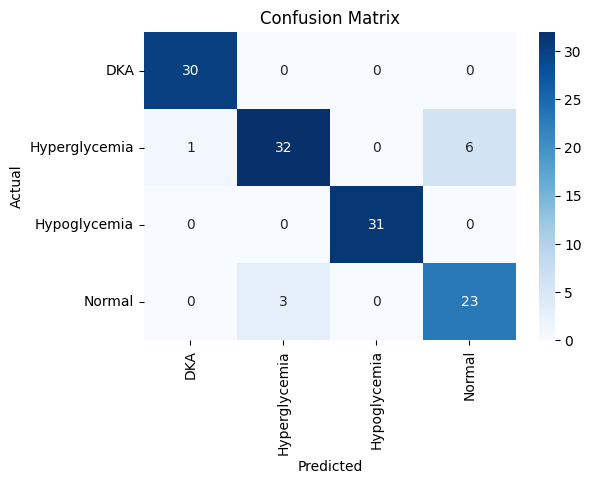

In [10]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [11]:
# Example: Glucose=150, Insulin=80, BloodPressure=70, Sweating=1, Nausea=0, Confusion=0, Thirst=1
import pandas as pd

# Create a DataFrame for the sample with correct feature names
sample = pd.DataFrame([[150, 80, 70, 1, 0, 0, 1]],
                      columns=["Glucose", "Insulin", "BloodPressure", "Sweating", "Nausea", "Confusion", "Thirst"])

# Predict
prediction = model.predict(sample)
print("Predicted Outcome:", prediction[0])


Predicted Outcome: Normal


In [12]:
MYSUGR_CSV = "data/mySugr_data/2022_01_09-2022_04_25_export.csv"
READER_FOLDER = "data/reader_data"   # folder with many reader CSVs

In [ ]:
# Load mySugr data
df_mysugr = pd.read_csv(MYSUGR_CSV)

# Create timestamp column in a more straightforward way
def create_timestamp(df):
    """Create timestamp from Date and Time columns"""
    try:
        # Combine date and time columns
        datetime_str = df['Date'] + ' ' + df['Time']
        
        # Convert to datetime
        return pd.to_datetime(datetime_str, format='%b %d, %Y %I:%M:%S %p')
    except:
        print("Columns found in data:", df.columns.tolist())
        raise ValueError("Could not create timestamp - check Date and Time columns")

# Create timestamp and handle missing values
if 'Date' in df_mysugr.columns and 'Time' in df_mysugr.columns:
    df_mysugr['timestamp'] = create_timestamp(df_mysugr)
    
    # Remove rows with invalid timestamps
    valid_rows = df_mysugr.dropna(subset=['timestamp'])
    
    print(f"Total rows: {len(df_mysugr)}")
    print(f"Valid timestamps: {len(valid_rows)}")
    print(f"Dropped rows: {len(df_mysugr) - len(valid_rows)}")
    
    df_mysugr = valid_rows
else:
    raise ValueError("Required columns 'Date' and 'Time' not found")

# Display first few rows
df_mysugr.head()

Total rows: 1787
Valid timestamps: 1787
Dropped rows: 0


,Date,Time,Tags,Blood Sugar Measurement (mmol/L),Insulin Injection Units (Pen),Basal Injection Units,Insulin Injection Units (pump),Insulin (Meal),Insulin (Correction),Temporary Basal Percentage,...,Steps,Note,Location,Blood pressure,Body weight (kg),HbA1c (Percent),Ketones,Food type,Medication,timestamp
0,"Apr 25, 2022",7:54:50 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25 19:54:50
1,"Apr 25, 2022",5:58:05 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25 17:58:05
2,"Apr 25, 2022",5:52:40 PM,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25 17:52:40
3,"Apr 25, 2022",4:52:51 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25 16:52:51
4,"Apr 25, 2022",2:26:00 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2022-04-25 14:26:00


In [ ]:
# column names
print("Available columns:", df_mysugr.columns.tolist())
if 'note' not in df_mysugr.columns.str.lower():
    raise ValueError("Note column not found in data")

Available columns: ['Date', 'Time', 'Tags', 'Blood Sugar Measurement (mmol/L)', 'Insulin Injection Units (Pen)', 'Basal Injection Units', 'Insulin Injection Units (pump)', 'Insulin (Meal)', 'Insulin (Correction)', 'Temporary Basal Percentage', 'Temporary Basal Duration (Minutes)', 'Meal Carbohydrates (Grams, Factor 1)', 'Meal Descriptions', 'Activity Duration (Minutes)', 'Activity Intensity (1: Cosy, 2: Ordinary, 3: Demanding)', 'Activity Description', 'Steps', 'Note', 'Location', 'Blood pressure', 'Body weight (kg)', 'HbA1c (Percent)', 'Ketones', 'Food type', 'Medication', 'timestamp']


In [ ]:
def process_mysugr_symptoms(df):
    """Extract symptoms from Note column and process insulin data"""
    
    # Process symptoms from Note column
    symptoms = {
        "Sweating": r"\b(sweat|sweaty|sweating)\b",
        "Nausea": r"\b(nausea|nauseous|vomit|vomiting)\b",
        "Confusion": r"\b(confus|dizzy|disoriented)\b",
        "Thirst": r"\b(thirst|thirsty|dehydrat|drink a lot)\b"
    }
    
    # Create symptom columns from Notes
    notes = df['Note'].fillna('').str.lower()
    for symptom, pattern in symptoms.items():
        df[symptom] = notes.str.contains(pattern, regex=True).astype(int) # 1 if symptom mentioned, else 0
    
    # Combine insulin columns
    insulin_cols = [
        'Insulin Injection Units (Pen)',
        'Basal Injection Units',
        'Insulin Injection Units (pump)',
        'Insulin (Meal)',
        'Insulin (Correction)'
    ]
    df['Insulin_mysugr'] = df[insulin_cols].fillna(0).sum(axis=1)
    
    # Select final columns
    keep_cols = ['timestamp', 'Insulin_mysugr', 'Sweating', 'Nausea', 'Confusion', 'Thirst']
    return df[keep_cols].copy()

# Process mySugr data
df_mysugr = process_mysugr_symptoms(df_mysugr)
df_mysugr.head()

/tmp/ipykernel_33660/3307754614.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[symptom] = notes.str.contains(pattern, regex=True).astype(int)
/tmp/ipykernel_33660/3307754614.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[symptom] = notes.str.contains(pattern, regex=True).astype(int)
/tmp/ipykernel_33660/3307754614.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[symptom] = notes.str.contains(pattern, regex=True).astype(int)
/tmp/ipykernel_33660/3307754614.py:15: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df[symptom] = notes.str.contains(pattern, regex=True).astype(int)


,timestamp,Insulin_mysugr,Sweating,Nausea,Confusion,Thirst
0,2022-04-25 19:54:50,0.0,0,0,0,0
1,2022-04-25 17:58:05,0.0,0,0,0,0
2,2022-04-25 17:52:40,8.0,0,0,0,0
3,2022-04-25 16:52:51,0.0,0,0,0,0
4,2022-04-25 14:26:00,0.0,0,0,0,0


In [15]:
# list reader files
from glob import glob
import os

import numpy as np


reader_files = sorted(glob(os.path.join(READER_FOLDER, "*.csv")))
print("Found reader files:", len(reader_files))

# read them (tab-separated) and concat
dfs = []
for f in reader_files:
    tmp = pd.read_csv(f, sep="\t", encoding="utf-8", engine="python")
    tmp.columns = tmp.columns.str.strip()
    dfs.append(tmp)
df_reader = pd.concat(dfs, ignore_index=True)

# create timestamp from reader Time column (example format: '2022/01/13 11:14')
if "Time" in df_reader.columns:
    df_reader["timestamp"] = pd.to_datetime(df_reader["Time"].astype(str).str.strip(), errors="coerce", infer_datetime_format=True)
else:
    raise SystemExit("Reader 'Time' column not found. Inspect df_reader.columns")

# combine glucose columns (scan or historic or strip) in mmol/L
glucose_cols = [c for c in ["Scan Glucose (mmol/L)", "Historic Glucose (mmol/L)", "Strip Glucose (mmol/L)"] if c in df_reader.columns]
df_reader["glucose_mmol"] = df_reader[glucose_cols].bfill(axis=1).iloc[:, 0]  # first non-null across the list

# convert to mg/dL
df_reader["Glucose"] = df_reader["glucose_mmol"] * 18

# combine insulin columns available in reader
reader_ins_cols = [c for c in df_reader.columns if "insulin" in c.lower()]
df_reader["Insulin_reader"] = df_reader[reader_ins_cols].fillna(0).sum(axis=1)

# keep useful reader cols
keep_reader = ["timestamp", "Glucose", "Insulin_reader"]
for c in keep_reader:
    if c not in df_reader.columns:
        df_reader[c] = np.nan

df_reader = df_reader[keep_reader].sort_values("timestamp").reset_index(drop=True)
df_reader.head()


Found reader files: 14


/tmp/ipykernel_33660/3527542048.py:21: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  df_reader["timestamp"] = pd.to_datetime(df_reader["Time"].astype(str).str.strip(), errors="coerce", infer_datetime_format=True)


,timestamp,Glucose,Insulin_reader
0,2020-11-02 18:09:00,140.4,0.0
1,2020-11-02 18:24:00,144.0,0.0
2,2020-11-02 18:38:00,136.8,0.0
3,2020-11-02 18:53:00,131.4,0.0
4,2020-11-02 19:08:00,131.4,0.0


In [16]:
# Merge mySugr and reader data on timestamp (nearest within 10 minutes)
df_mysugr = df_mysugr.sort_values("timestamp")
df_reader = df_reader.sort_values("timestamp")
df_merged = pd.merge_asof(
    df_reader, df_mysugr,
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("10m")
)

# Insulin: prefer mySugr insulin if present (user-entered), else use reader insulin
df_merged["Insulin"] = df_merged["Insulin_mysugr"].fillna(0) + df_merged["Insulin_reader"].fillna(0)

# BloodPressure: not present → use default 120 (or NaN if you prefer)
df_merged["BloodPressure"] = 120   # simple default

# fill symptoms with 0 if NaN
for col in ["Sweating", "Nausea", "Confusion", "Thirst"]:
    if col not in df_merged.columns:
        df_merged[col] = 0
    df_merged[col] = df_merged[col].fillna(0).astype(int)

# Keep final feature dataframe
feature_cols = ["Glucose", "Insulin", "BloodPressure", "Sweating", "Nausea", "Confusion", "Thirst"]
df_test = df_merged[feature_cols].copy().fillna(0).astype(float)
df_test.head()


,Glucose,Insulin,BloodPressure,Sweating,Nausea,Confusion,Thirst
0,140.4,0.0,120.0,0.0,0.0,0.0,0.0
1,144.0,0.0,120.0,0.0,0.0,0.0,0.0
2,136.8,0.0,120.0,0.0,0.0,0.0,0.0
3,131.4,0.0,120.0,0.0,0.0,0.0,0.0
4,131.4,0.0,120.0,0.0,0.0,0.0,0.0


In [17]:
# Predict (pass DataFrame with same column names)
preds = model.predict(df_test)

# Attach predictions back to merged df
df_merged["Predicted_Outcome"] = preds

# Show a few rows with Time, Glucose, symptoms and prediction
display_cols = ["timestamp", "Glucose", "Insulin", "Sweating", "Nausea", "Confusion", "Thirst", "Predicted_Outcome"]
df_merged[display_cols].head(10)


,timestamp,Glucose,Insulin,Sweating,Nausea,Confusion,Thirst,Predicted_Outcome
0,2020-11-02 18:09:00,140.4,0.0,0,0,0,0,Hyperglycemia
1,2020-11-02 18:24:00,144.0,0.0,0,0,0,0,Hyperglycemia
2,2020-11-02 18:38:00,136.8,0.0,0,0,0,0,Hyperglycemia
3,2020-11-02 18:53:00,131.4,0.0,0,0,0,0,Hyperglycemia
4,2020-11-02 19:08:00,131.4,0.0,0,0,0,0,Hyperglycemia
5,2020-11-02 19:24:00,135.0,0.0,0,0,0,0,Hyperglycemia
6,2020-11-02 19:39:00,138.6,0.0,0,0,0,0,Hyperglycemia
7,2020-11-02 19:54:00,145.8,0.0,0,0,0,0,Hyperglycemia
8,2020-11-02 20:08:00,154.8,0.0,0,0,0,0,Hyperglycemia
9,2020-11-02 20:23:00,160.2,0.0,0,0,0,0,Hyperglycemia


In [18]:
def glucose_label(g):
    if pd.isna(g): return "Unknown"
    if g < 70: return "Hypoglycemia"
    if g > 250: return "DKA"
    if g > 180: return "Hyperglycemia"
    return "Normal"

df_merged["Outcome_from_Glucose"] = df_merged["Glucose"].apply(glucose_label)

# Show comparison counts
print("Predicted counts:\n", df_merged["Predicted_Outcome"].value_counts(dropna=False))
print("\nGlucose-derived counts:\n", df_merged["Outcome_from_Glucose"].value_counts(dropna=False))

# Confusion matrix between predicted and glucose-derived label (helpful quick check)
from sklearn.metrics import confusion_matrix, classification_report
y_true = df_merged["Outcome_from_Glucose"]
y_pred  = df_merged["Predicted_Outcome"]

# Filter out Unknown rows
mask = y_true != "Unknown"
print("\nAccuracy vs glucose-derived labels:", (y_true[mask] == y_pred[mask]).mean())
print("\nClassification report (vs glucose-derived):\n", classification_report(y_true[mask], y_pred[mask], zero_division=0))


Predicted counts:
 Predicted_Outcome
Hyperglycemia    93244
Normal           68850
Hypoglycemia     12252
DKA               2627
Name: count, dtype: int64

Glucose-derived counts:
 Outcome_from_Glucose
Normal           125868
Hyperglycemia     32467
Hypoglycemia      10436
DKA                6386
Unknown            1816
Name: count, dtype: int64

Accuracy vs glucose-derived labels: 0.6530141530170076

Classification report (vs glucose-derived):
                precision    recall  f1-score   support

          DKA       1.00      0.41      0.58      6386
Hyperglycemia       0.35      1.00      0.52     32467
 Hypoglycemia       1.00      1.00      1.00     10436
       Normal       1.00      0.55      0.71    125868

     accuracy                           0.65    175157
    macro avg       0.84      0.74      0.70    175157
 weighted avg       0.88      0.65      0.68    175157

